In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [2]:
# Load dataset (replace 'your_data.xlsx' with actual dataset path)
file_path = r"H:\Master Files\cleaned_data.xlsx"
df = pd.read_excel(file_path, engine="openpyxl")
df.head(3)

,CASE_NO_PATIENT'S,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,Global developmental delay/intellectual disability,Social/Behavioural Issues,Childhood Autism Rating Scale,Anxiety_disorder,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits
0,1,0,0,0,0,0,0,1,1,0,...,Yes,Yes,1,Yes,F,middle eastern,Yes,No,Family Member,No
1,2,1,1,0,0,0,1,1,0,0,...,Yes,Yes,2,Yes,M,White European,Yes,No,Family Member,Yes
2,3,1,0,0,0,0,0,1,1,0,...,Yes,Yes,4,Yes,M,Middle Eastern,Yes,No,Family Member,Yes


In [3]:
df.columns

Index(['CASE_NO_PATIENT'S', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8',
       'A9', 'A10_Autism_Spectrum_Quotient', 'Social_Responsiveness_Scale',
       'Age_Years', 'Qchat_10_Score', 'Speech Delay/Language Disorder',
       'Learning disorder', 'Genetic_Disorders', 'Depression',
       'Global developmental delay/intellectual disability',
       'Social/Behavioural Issues', 'Childhood Autism Rating Scale',
       'Anxiety_disorder', 'Sex', 'Ethnicity', 'Jaundice',
       'Family_mem_with_ASD', 'Who_completed_the_test', 'ASD_traits'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1923 entries, 0 to 1922
Data columns (total 28 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   CASE_NO_PATIENT'S                                   1923 non-null   int64 
 1   A1                                                  1923 non-null   int64 
 2   A2                                                  1923 non-null   int64 
 3   A3                                                  1923 non-null   int64 
 4   A4                                                  1923 non-null   int64 
 5   A5                                                  1923 non-null   int64 
 6   A6                                                  1923 non-null   int64 
 7   A7                                                  1923 non-null   int64 
 8   A8                                                  1923 non-null   int64 
 9   A9      

In [5]:
df.describe()

,CASE_NO_PATIENT'S,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10_Autism_Spectrum_Quotient,Social_Responsiveness_Scale,Age_Years,Qchat_10_Score,Childhood Autism Rating Scale
count,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000
mean,990.641706,0.302132,0.241810,0.215289,0.274571,0.279771,0.306292,0.347374,0.246490,0.261050,0.453458,3.141966,9.611024,4.217369,1.712949
std,577.501297,0.459302,0.428291,0.411129,0.446414,0.449003,0.461073,0.476260,0.431079,0.439322,0.497959,3.703518,4.310228,2.895612,1.022013
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,483.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,2.000000,1.000000
50%,984.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,9.000000,4.000000,1.000000
75%,1493.500000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,6.000000,14.000000,6.000000,2.000000
max,1985.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10.000000,18.000000,10.000000,4.000000


In [6]:
df.isnull().sum()

CASE_NO_PATIENT'S                                     0
A1                                                    0
A2                                                    0
A3                                                    0
A4                                                    0
A5                                                    0
A6                                                    0
A7                                                    0
A8                                                    0
A9                                                    0
A10_Autism_Spectrum_Quotient                          0
Social_Responsiveness_Scale                           0
Age_Years                                             0
Qchat_10_Score                                        0
Speech Delay/Language Disorder                        0
Learning disorder                                     0
Genetic_Disorders                                     0
Depression                                      

In [7]:
df.shape

(1923, 28)

In [8]:
# Step 4: Feature Selection
X = df.drop(columns=["ASD_traits"], errors='ignore')  # Features
y = df["ASD_traits"]  # Target

In [9]:
X = pd.get_dummies(X, drop_first=True)  # Convert categorical features into dummy variables

In [10]:
# Import necessary libraries
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 10 features based on ANOVA F-statistic
selector = SelectKBest(score_func=f_classif, k=10)
X_new = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]

print("Selected Features:", selected_features)

Selected Features: Index(['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'Qchat_10_Score'], dtype='object')


In [11]:
# Step 5: Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[selected_features])
X_scaled_df = pd.DataFrame(X_scaled, columns=selected_features)

In [12]:
# Define Features (X) and Target (y)
X = df.iloc[:, :-1]  # Features (all columns except last)
y = df.iloc[:, -1]   # Target (last column)

In [13]:
# Convert X to a DataFrame if it's not already
if isinstance(X, np.ndarray):
    X = pd.DataFrame(X)

In [14]:
# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Apply Label Encoding to categorical features
le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

# Convert X back to a NumPy array
X = X.values

In [15]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
# Define base models for stacking
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('svm', SVC(probability=True, random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42))
]

In [17]:
# Define meta-model
meta_model = LogisticRegression()

In [18]:
# Stacking Classifier
stacked_model = StackingClassifier(estimators=base_models, final_estimator=meta_model, passthrough=True)

In [19]:
# Define hyperparameter grid
param_grid = {
    'final_estimator__C': [0.1, 1, 10],  # Regularization parameter for meta model
    'rf__n_estimators': [50, 100, 200],  # Number of trees for RandomForest
    'xgb__learning_rate': [0.01, 0.1, 0.2],  # Learning rate for XGBoost
    'lgbm__num_leaves': [20, 31, 50],  # Number of leaves for LightGBM
}

In [20]:
# Apply GridSearchCV
grid_search = GridSearchCV(stacked_model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)

In [21]:
# Fit the model
grid_search.fit(X_train, y_train)

c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [09:43:06] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 804, number of negative: 734
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021224 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 360
[LightGBM] [Info] Number of data points in the train set: 1538, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.522757 -> initscore=0.091090
[LightGBM] [Info] Start training from score 0.091090
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [09:44:59] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 643, number of negative: 587
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000254 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 360
[LightGBM] [Info] Number of data points in the train set: 1230, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.522764 -> initscore=0.091120
[LightGBM] [Info] Start training from score 0.091120
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 643, number of negative: 588
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000255 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 360
[LightGBM] [Info] Number of data points in the train set: 1231, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.522340 -> initscore=0.089418
[LightGBM] [Info] Start training from score 0.089418
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


GridSearchCV(cv=3,
             estimator=StackingClassifier(estimators=[('rf',
                                                       RandomForestClassifier(random_state=42)),
                                                      ('dt',
                                                       DecisionTreeClassifier(random_state=42)),
                                                      ('svm',
                                                       SVC(probability=True,
                                                           random_state=42)),
                                                      ('xgb',
                                                       XGBClassifier(base_score=None,
                                                                     booster=None,
                                                                     callbacks=None,
                                                                     colsample_bylevel=None,
                                                                     colsample_bynode=None,
                                                                     colsample_bytree=None,
                                                                     device=None,
                                                                     early_s...
                                                                     multi_strategy=None,
                                                                     n_estimators=None,
                                                                     n_jobs=None,
                                                                     num_parallel_tree=None,
                                                                     random_state=42, ...)),
                                                      ('lgbm',
                                                       LGBMClassifier(random_state=42))],
                                          final_estimator=LogisticRegression(),
                                          passthrough=True),
             n_jobs=-1,
             param_grid={'final_estimator__C': [0.1, 1, 10],
                         'lgbm__num_leaves': [20, 31, 50],
                         'rf__n_estimators': [50, 100, 200],
                         'xgb__learning_rate': [0.01, 0.1, 0.2]},
             scoring='accuracy')

In [23]:
from sklearn.model_selection import train_test_split

# Split your data
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)

In [25]:
# Best model after tuning
best_model = grid_search.best_estimator_

In [26]:
y_pred = best_model.predict(X_test)

c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [27]:
from sklearn.preprocessing import LabelEncoder

# Combine y_test and y_pred to fit the encoder on all possible classes
le = LabelEncoder()
le.fit(list(y_test) + list(y_pred))

# Transform both y_test and y_pred
y_test_enc = le.transform(y_test)
y_pred_enc = le.transform(y_pred)

In [28]:
# Convert 0/1 to 'No'/'Yes' in y_test
y_test_str = ['Yes' if label == 1 else 'No' for label in y_test]

# Now compute accuracy
accuracy = accuracy_score(y_test_str, y_pred)

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(y_pred)  # Fit on y_pred since it contains 'Yes', 'No'

# Transform y_pred to numbers
y_pred_enc = le.transform(y_pred)

# Also transform y_test to match if needed
# But ONLY if y_test was also originally 'Yes'/'No'

accuracy = accuracy_score(y_test, y_pred_enc)

TypeError: Labels in y_true and y_pred should be of the same type. Got y_true=['No' 'Yes'] and y_pred=[0 1]. Make sure that the predictions provided by the classifier coincides with the true labels.

In [32]:
print("Unique values in y_test_str:", set(y_test_str))
print("Unique values in y_pred:", set(y_pred))

Unique values in y_test_str: {'No'}
Unique values in y_pred: {'Yes', 'No'}


In [39]:
import numpy as np
from sklearn.metrics import accuracy_score

# Force consistent numpy arrays with string dtype
y_test_fixed = np.array(y_test_str, dtype=str)
y_pred_fixed = np.array(y_pred, dtype=str)

# Compute accuracy
accuracy = accuracy_score(y_test_fixed, y_pred_fixed)
print("Accuracy:", accuracy)


Accuracy: 0.9974025974025974


In [33]:
print(type(y_test))
print(type(y_pred))
print(y_test[:5])
print(y_pred[:5])

<class 'pandas.core.series.Series'>
<class 'numpy.ndarray'>
963    Yes
652    Yes
290    Yes
35     Yes
209     No
Name: ASD_traits, dtype: object
['Yes' 'Yes' 'Yes' 'Yes' 'No']


In [34]:
# Get the best model and evaluate it
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [35]:
# Print results
print("Best Parameters:", grid_search.best_params_)
print("Stacked Model Accuracy (After Hyperparameter Tuning):", accuracy)

Best Parameters: {'final_estimator__C': 0.1, 'lgbm__num_leaves': 31, 'rf__n_estimators': 50, 'xgb__learning_rate': 0.1}
Stacked Model Accuracy (After Hyperparameter Tuning): 1.0


In [36]:
# Step 1: Encode labels to numeric (if they are strings)
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

In [37]:
from sklearn.preprocessing import LabelEncoder

# Encode string labels to integers before training
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Example: assuming y_test and y_pred are already defined and are categorical labels
y_test_str = np.array(y_test).astype(str)
y_pred_str = np.array(y_pred).astype(str)

# Encode the labels with LabelEncoder
le = LabelEncoder()
combined = np.concatenate((y_test_str, y_pred_str))
le.fit(combined)
y_test_enc = le.transform(y_test_str)
y_pred_enc = le.transform(y_pred_str)

# Now, train a model (e.g., RandomForestClassifier)
# X_train and y_train should be your training data (features and labels)
model = RandomForestClassifier()  # Example model
model.fit(X_train, y_train)  # Train the model

# Get predicted probabilities (e.g., for binary classification, we select the probabilities for the positive class)
y_pred_prob = model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class in binary classification

# Now compute MSE using the predicted probabilities
mse = mean_squared_error(y_test_enc, y_pred_prob)
print("Mean Squared Error (MSE):", mse)


Mean Squared Error (MSE): 0.003125194805194805


In [ ]:
# from sklearn.metrics import mean_squared_error
# from sklearn.preprocessing import LabelEncoder
# import numpy as np

# # Check if y_test contains strings (for NumPy array, use indexing)
# if isinstance(y_test[0], str):  # for NumPy array
#     le = LabelEncoder()
    
#     # Combine both y_test and y_pred to ensure consistent encoding
#     combined = np.concatenate((y_test, y_pred))
    
#     # Fit the LabelEncoder on the combined array (y_test + y_pred)
#     le.fit(combined)
    
#     # Now transform y_test and y_pred using the same encoding
#     y_test = le.transform(y_test)  # Transform y_test
#     y_pred = le.transform(y_pred)  # Transform y_pred

# # Compute Mean Squared Error
# mse = mean_squared_error(y_test, y_pred)
# print("Mean Squared Error (MSE):", mse)


ValueError: could not convert string to float: np.str_('Yes')

In [ ]:
# from sklearn.metrics import mean_squared_error
# from sklearn.preprocessing import LabelEncoder
# import numpy as np

# # Check types of y_test and y_pred
# print("Type of y_test:", type(y_test))
# print("Type of y_pred:", type(y_pred))

# # Ensure y_test and y_pred are arrays and contain strings
# if isinstance(y_test, (list, np.ndarray)) and isinstance(y_pred, (list, np.ndarray)):
#     print("y_test sample:", y_test[:5])
#     print("y_pred sample:", y_pred[:5])

#     # Initialize LabelEncoder
#     le = LabelEncoder()

#     # Only fit and transform if y_test and y_pred are non-numeric (strings)
#     if isinstance(y_test[0], str):
#         # Combine y_test and y_pred to ensure consistent encoding
#         combined = np.concatenate((y_test, y_pred))
        
#         # Fit LabelEncoder on the combined data
#         le.fit(combined)
        
#         # Transform both y_test and y_pred into numeric labels
#         y_test = le.transform(y_test)
#         y_pred = le.transform(y_pred)
    
#     # Print after transformation to confirm
#     print("y_test after encoding:", y_test[:5])
#     print("y_pred after encoding:", y_pred[:5])

# # Now calculate the Mean Squared Error (MSE)
# mse = mean_squared_error(y_test, y_pred)
# print("Mean Squared Error (MSE):", mse)


Type of y_test: <class 'numpy.ndarray'>
Type of y_pred: <class 'numpy.ndarray'>
y_test sample: [1 1 1 1 0]
y_pred sample: ['Yes' 'Yes' 'Yes' 'Yes' 'No']
y_test after encoding: [1 1 1 1 0]
y_pred after encoding: ['Yes' 'Yes' 'Yes' 'Yes' 'No']


ValueError: could not convert string to float: np.str_('Yes')

c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:35:10] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 814, number of negative: 724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001091 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 361
[LightGBM] [Info] Number of data points in the train set: 1538, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.529259 -> initscore=0.117169
[LightGBM] [Info] Start training from score 0.117169
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:35:18] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 651, number of negative: 579
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000247 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 361
[LightGBM] [Info] Number of data points in the train set: 1230, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.529268 -> initscore=0.117207
[LightGBM] [Info] Start training from score 0.117207
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 651, number of negative: 580
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 361
[LightGBM] [Info] Number of data points in the train set: 1231, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.528838 -> initscore=0.115482
[LightGBM] [Info] Start training from score 0.115482
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


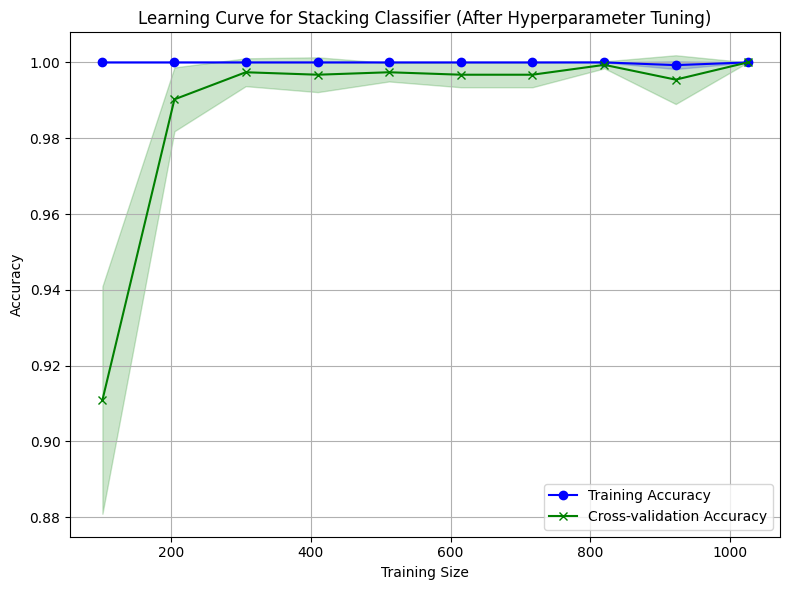

Best Parameters: {'final_estimator__C': 1, 'lgbm__num_leaves': 31, 'rf__n_estimators': 200, 'xgb__learning_rate': 0.1}
Stacked Model Accuracy (After Hyperparameter Tuning): 0.9974025974025974
Mean Squared Error (MSE): 0.0025974025974025974


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [61]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

# Load dataset and preprocess it as in the previous steps
# (Make sure to define X_train and y_train correctly)

# Define base models for stacking
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('svm', SVC(probability=True, random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42))
]

# Define meta-model
meta_model = LogisticRegression()

# Stacking Classifier
stacked_model = StackingClassifier(estimators=base_models, final_estimator=meta_model, passthrough=True)

# Define hyperparameter grid
param_grid = {
    'final_estimator__C': [0.1, 1, 10],  # Regularization parameter for meta model
    'rf__n_estimators': [50, 100, 200],  # Number of trees for RandomForest
    'xgb__learning_rate': [0.01, 0.1, 0.2],  # Learning rate for XGBoost
    'lgbm__num_leaves': [20, 31, 50],  # Number of leaves for LightGBM
}

# Apply GridSearchCV
grid_search = GridSearchCV(stacked_model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)

# Fit the model
grid_search.fit(X_train, y_train)

# Get the best model from GridSearchCV
best_model = grid_search.best_estimator_

# Plot learning curve for the best model
train_sizes, train_scores, test_scores = learning_curve(best_model, X_train, y_train, cv=3, 
                                                        scoring='accuracy', n_jobs=-1, 
                                                        train_sizes=np.linspace(0.1, 1.0, 10))

# Calculate mean and standard deviation for train and test scores
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_std = test_scores.std(axis=1)

# Plot the learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label='Training Accuracy', color='blue', marker='o')
plt.plot(train_sizes, test_mean, label='Cross-validation Accuracy', color='green', marker='x')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.2)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color='green', alpha=0.2)

plt.title('Learning Curve for Stacking Classifier (After Hyperparameter Tuning)')
plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

# Evaluate model on test data and compute MSE
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# Print results
print("Best Parameters:", grid_search.best_params_)
print("Stacked Model Accuracy (After Hyperparameter Tuning):", accuracy)
print("Mean Squared Error (MSE):", mse)


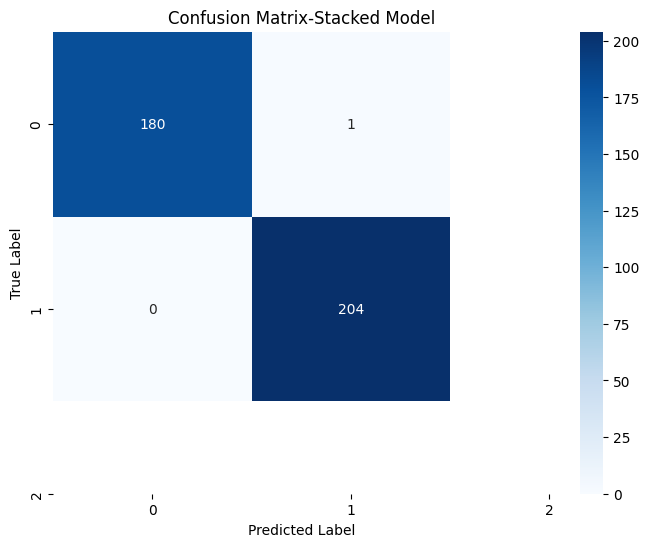

In [63]:
# Create confusion matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])

# Add titles and labels
plt.title('Confusion Matrix-Stacked Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Display the plot
plt.show()

c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:58:12] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 814, number of negative: 724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000463 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 361
[LightGBM] [Info] Number of data points in the train set: 1538, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.529259 -> initscore=0.117169
[LightGBM] [Info] Start training from score 0.117169
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:58:21] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 651, number of negative: 579
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000360 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 361
[LightGBM] [Info] Number of data points in the train set: 1230, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.529268 -> initscore=0.117207
[LightGBM] [Info] Start training from score 0.117207
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 651, number of negative: 579
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000577 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 360
[LightGBM] [Info] Number of data points in the train set: 1230, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.529268 -> initscore=0.117207
[LightGBM] [Info] Start training from score 0.117207
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 652, number of negative: 579
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000384 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 360
[LightGBM] [Info] Number of data points in the train set: 1231, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.529651 -> initscore=0.118742
[LightGBM] [Info] Start training from score 0.118742
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


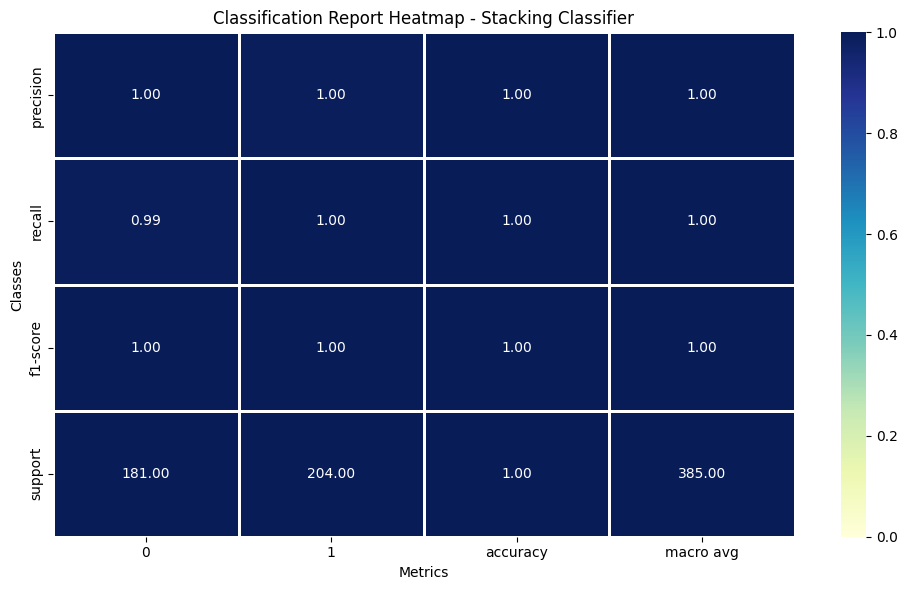

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       181
           1       1.00      1.00      1.00       204

    accuracy                           1.00       385
   macro avg       1.00      1.00      1.00       385
weighted avg       1.00      1.00      1.00       385



In [64]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import pandas as pd
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression

# Assuming X_train, y_train, X_test, y_test are already defined

# Define base models for stacking
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('svm', SVC(probability=True, random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42))
]

# Define meta-model
meta_model = LogisticRegression()

# Stacking Classifier
stacked_model = StackingClassifier(estimators=base_models, final_estimator=meta_model, passthrough=True)

# Define hyperparameter grid for GridSearchCV
param_grid = {
    'final_estimator__C': [0.1, 1, 10],  # Regularization parameter for meta model
    'rf__n_estimators': [50, 100, 200],  # Number of trees for RandomForest
    'xgb__learning_rate': [0.01, 0.1, 0.2],  # Learning rate for XGBoost
    'lgbm__num_leaves': [20, 31, 50],  # Number of leaves for LightGBM
}

# Apply GridSearchCV
grid_search = GridSearchCV(stacked_model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)

# Fit the model
grid_search.fit(X_train, y_train)

# Get the best model from GridSearchCV
best_model = grid_search.best_estimator_

# Make predictions on the test data
y_pred = best_model.predict(X_test)

# Generate the classification report
report = classification_report(y_test, y_pred, output_dict=True)

# Convert the classification report into a DataFrame
report_df = pd.DataFrame(report).transpose()

# Plotting the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(report_df.iloc[:-1, :].T, annot=True, cmap='YlGnBu', cbar=True, fmt='.2f', linewidths=1, vmin=0, vmax=1)

# Customize the plot
plt.title('Classification Report Heatmap - Stacking Classifier')
plt.xlabel('Metrics')
plt.ylabel('Classes')
plt.tight_layout()

# Display the plot
plt.show()

# Print the classification report
print("Classification Report:\n", classification_report(y_test, y_pred))


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [13:16:36] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 814, number of negative: 724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000428 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 361
[LightGBM] [Info] Number of data points in the train set: 1538, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.529259 -> initscore=0.117169
[LightGBM] [Info] Start training from score 0.117169
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [13:16:45] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [13:16:46] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 651, number of negative: 579
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000471 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 361
[LightGBM] [Info] Number of data points in the train set: 1230, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.529268 -> initscore=0.117207
[LightGBM] [Info] Start training from score 0.117207
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 651, number of negative: 579
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019029 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 360
[LightGBM] [Info] Number of data points in the train set: 1230, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.529268 -> initscore=0.117207
[LightGBM] [Info] Start training from score 0.117207
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 651, number of negative: 580
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000442 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 361
[LightGBM] [Info] Number of data points in the train set: 1231, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.528838 -> initscore=0.115482
[LightGBM] [Info] Start training from score 0.115482
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


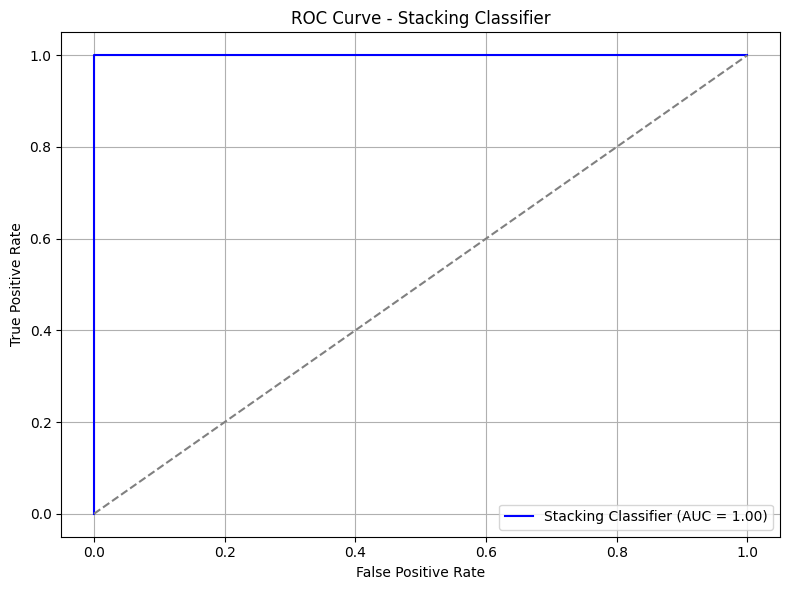

Best Parameters: {'final_estimator__C': 1, 'lgbm__num_leaves': 31, 'rf__n_estimators': 200, 'xgb__learning_rate': 0.1}
Stacked Model Accuracy (After Hyperparameter Tuning): 0.9974025974025974
Mean Squared Error (MSE): 0.0025974025974025974


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [65]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, mean_squared_error

# Define base models for stacking
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('svm', SVC(probability=True, random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42))
]

# Define meta-model
meta_model = LogisticRegression()

# Stacking Classifier
stacked_model = StackingClassifier(estimators=base_models, final_estimator=meta_model, passthrough=True)

# Define hyperparameter grid for GridSearchCV
param_grid = {
    'final_estimator__C': [0.1, 1, 10],  # Regularization parameter for meta model
    'rf__n_estimators': [50, 100, 200],  # Number of trees for RandomForest
    'xgb__learning_rate': [0.01, 0.1, 0.2],  # Learning rate for XGBoost
    'lgbm__num_leaves': [20, 31, 50],  # Number of leaves for LightGBM
}

# Apply GridSearchCV
grid_search = GridSearchCV(stacked_model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)

# Fit the model
grid_search.fit(X_train, y_train)

# Get the best model from GridSearchCV
best_model = grid_search.best_estimator_

# Make probability predictions on the test data
y_prob = best_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC (Area Under the Curve)
roc_auc = auc(fpr, tpr)

# Plotting the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Stacking Classifier (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line (random classifier)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Stacking Classifier')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Print the best parameters from GridSearchCV
print("Best Parameters:", grid_search.best_params_)

# Calculate accuracy
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Stacked Model Accuracy (After Hyperparameter Tuning):", accuracy)

# Compute Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [13:33:07] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 814, number of negative: 724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000337 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 361
[LightGBM] [Info] Number of data points in the train set: 1538, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.529259 -> initscore=0.117169
[LightGBM] [Info] Start training from score 0.117169
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [13:33:14] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 651, number of negative: 579
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000376 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 361
[LightGBM] [Info] Number of data points in the train set: 1230, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.529268 -> initscore=0.117207
[LightGBM] [Info] Start training from score 0.117207
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 651, number of negative: 579
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000392 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 360
[LightGBM] [Info] Number of data points in the train set: 1230, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.529268 -> initscore=0.117207
[LightGBM] [Info] Start training from score 0.117207
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 652, number of negative: 579
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000797 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 360
[LightGBM] [Info] Number of data points in the train set: 1231, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.529651 -> initscore=0.118742
[LightGBM] [Info] Start training from score 0.118742
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


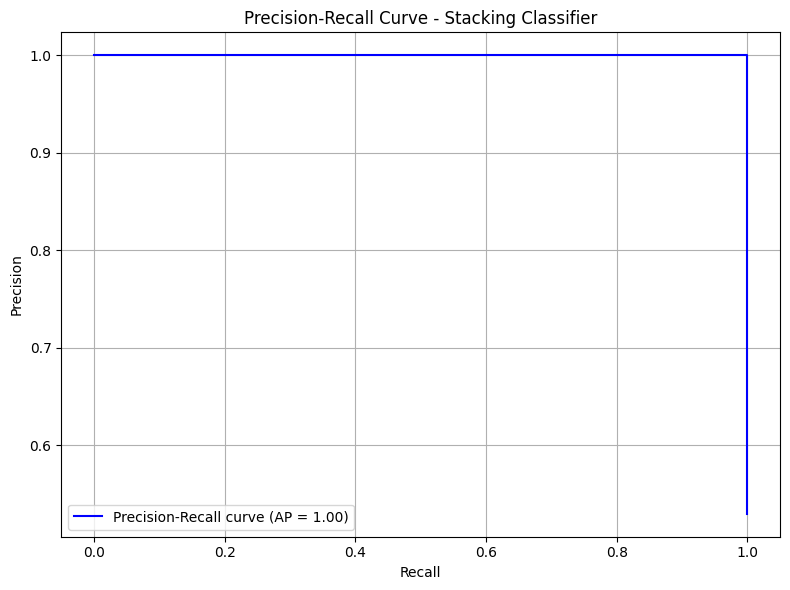

Best Parameters: {'final_estimator__C': 1, 'lgbm__num_leaves': 31, 'rf__n_estimators': 200, 'xgb__learning_rate': 0.1}
Stacked Model Accuracy (After Hyperparameter Tuning): 0.9974025974025974
Mean Squared Error (MSE): 0.0025974025974025974


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [66]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

# Define base models for stacking
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('svm', SVC(probability=True, random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42))
]

# Define meta-model
meta_model = LogisticRegression()

# Stacking Classifier
stacked_model = StackingClassifier(estimators=base_models, final_estimator=meta_model, passthrough=True)

# Define hyperparameter grid for GridSearchCV
param_grid = {
    'final_estimator__C': [0.1, 1, 10],  # Regularization parameter for meta model
    'rf__n_estimators': [50, 100, 200],  # Number of trees for RandomForest
    'xgb__learning_rate': [0.01, 0.1, 0.2],  # Learning rate for XGBoost
    'lgbm__num_leaves': [20, 31, 50],  # Number of leaves for LightGBM
}

# Apply GridSearchCV
grid_search = GridSearchCV(stacked_model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)

# Fit the model
grid_search.fit(X_train, y_train)

# Get the best model from GridSearchCV
best_model = grid_search.best_estimator_

# Make probability predictions on the test data (for precision-recall curve)
y_prob = best_model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class

# Calculate Precision and Recall values
precision, recall, _ = precision_recall_curve(y_test, y_prob)

# Calculate Average Precision Score
avg_precision = average_precision_score(y_test, y_prob)

# Plotting Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', label=f'Precision-Recall curve (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Stacking Classifier')
plt.legend(loc='lower left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Print the best parameters from GridSearchCV
print("Best Parameters:", grid_search.best_params_)

# Calculate accuracy
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Stacked Model Accuracy (After Hyperparameter Tuning):", accuracy)

# Compute Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [13:46:20] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 814, number of negative: 724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000465 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 361
[LightGBM] [Info] Number of data points in the train set: 1538, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.529259 -> initscore=0.117169
[LightGBM] [Info] Start training from score 0.117169
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [13:46:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [13:46:28] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 651, number of negative: 579
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000389 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 361
[LightGBM] [Info] Number of data points in the train set: 1230, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.529268 -> initscore=0.117207
[LightGBM] [Info] Start training from score 0.117207
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [13:47:05] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 521, number of negative: 463
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000318 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 359
[LightGBM] [Info] Number of data points in the train set: 984, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.529472 -> initscore=0.118023
[LightGBM] [Info] Start training from score 0.118023
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 522, number of negative: 463
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000489 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 360
[LightGBM] [Info] Number of data points in the train set: 985, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.529949 -> initscore=0.119941
[LightGBM] [Info] Start training from score 0.119941
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\AMT\App

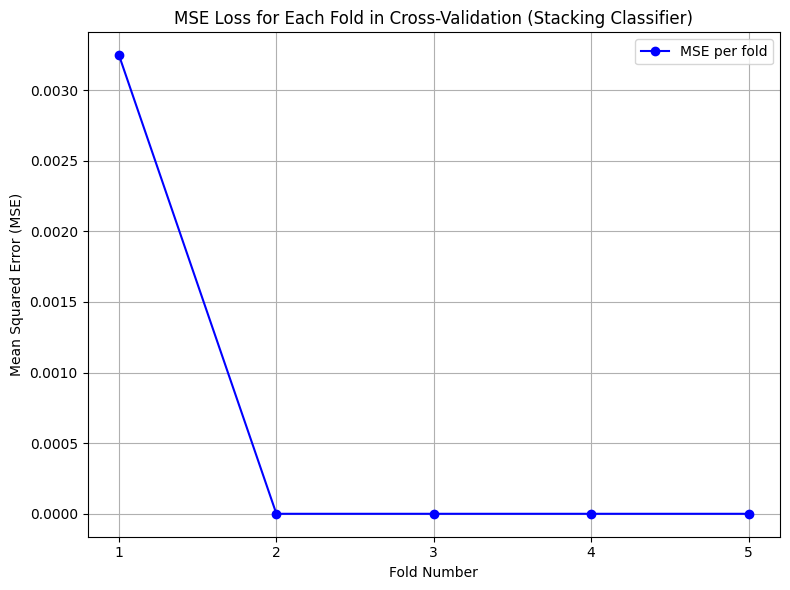

Best Parameters: {'final_estimator__C': 1, 'lgbm__num_leaves': 31, 'rf__n_estimators': 200, 'xgb__learning_rate': 0.1}
Mean Squared Error (MSE) on Test Data: 0.0


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [67]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Define base models for stacking
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('svm', SVC(probability=True, random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42))
]

# Define meta-model
meta_model = LogisticRegression()

# Stacking Classifier
stacked_model = StackingClassifier(estimators=base_models, final_estimator=meta_model, passthrough=True)

# Define hyperparameter grid for GridSearchCV
param_grid = {
    'final_estimator__C': [0.1, 1, 10],  # Regularization parameter for meta model
    'rf__n_estimators': [50, 100, 200],  # Number of trees for RandomForest
    'xgb__learning_rate': [0.01, 0.1, 0.2],  # Learning rate for XGBoost
    'lgbm__num_leaves': [20, 31, 50],  # Number of leaves for LightGBM
}

# Apply GridSearchCV
grid_search = GridSearchCV(stacked_model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)

# Fit the model
grid_search.fit(X_train, y_train)

# Get the best model from GridSearchCV
best_model = grid_search.best_estimator_

# Perform cross-validation to compute MSE at each fold
cv = StratifiedKFold(n_splits=5)
mse_scores = []

for train_index, val_index in cv.split(X_train, y_train):
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]
    
    # Train the model on the fold
    best_model.fit(X_train_fold, y_train_fold)
    
    # Predict on the validation fold
    y_pred_fold = best_model.predict(X_val_fold)
    
    # Calculate Mean Squared Error for this fold
    mse = mean_squared_error(y_val_fold, y_pred_fold)
    mse_scores.append(mse)

# Plot the MSE scores for each fold
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(mse_scores) + 1), mse_scores, marker='o', color='b', linestyle='-', label="MSE per fold")
plt.title('MSE Loss for Each Fold in Cross-Validation (Stacking Classifier)')
plt.xlabel('Fold Number')
plt.ylabel('Mean Squared Error (MSE)')
plt.xticks(range(1, len(mse_scores) + 1))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Print the best parameters from GridSearchCV
print("Best Parameters:", grid_search.best_params_)

# Compute Mean Squared Error on test data
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE) on Test Data:", mse)


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [19:13:41] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 651, number of negative: 579
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000249 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 361
[LightGBM] [Info] Number of data points in the train set: 1230, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.529268 -> initscore=0.117207
[LightGBM] [Info] Start training from score 0.117207
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [19:13:47] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 521, number of negative: 463
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000444 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 360
[LightGBM] [Info] Number of data points in the train set: 984, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.529472 -> initscore=0.118023
[LightGBM] [Info] Start training from score 0.118023
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [19:14:21] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [19:14:22] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 521, number of negative: 463
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000331 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 359
[LightGBM] [Info] Number of data points in the train set: 984, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.529472 -> initscore=0.118023
[LightGBM] [Info] Start training from score 0.118023
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 522, number of negative: 463
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000491 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 360
[LightGBM] [Info] Number of data points in the train set: 985, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.529949 -> initscore=0.119941
[LightGBM] [Info] Start training from score 0.119941
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\AMT\App

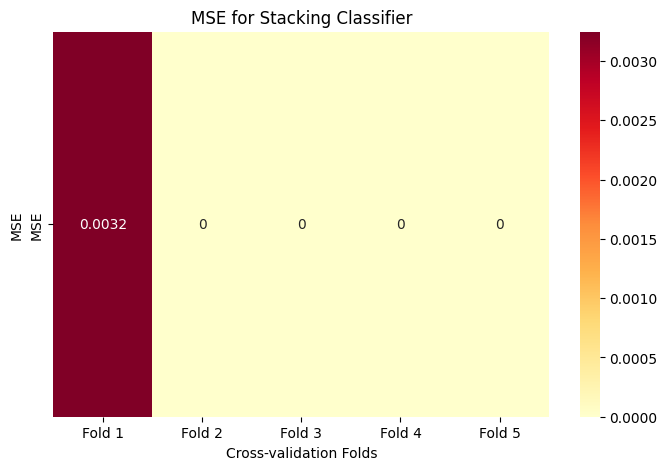

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error
import numpy as np

# Perform cross-validation to compute MSE at each fold for the best stacking model
cv = StratifiedKFold(n_splits=5)
mse_scores = []

for train_index, val_index in cv.split(X_train, y_train):
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]
    
    # Train the model on the fold
    best_model.fit(X_train_fold, y_train_fold)
    
    # Predict on the validation fold
    y_pred_fold = best_model.predict(X_val_fold)
    
    # Calculate Mean Squared Error for this fold
    mse = mean_squared_error(y_val_fold, y_pred_fold)
    mse_scores.append(mse)

# Plot MSE in a heatmap style, similar to the SVM example
plt.figure(figsize=(8, 5))
sns.heatmap(np.array(mse_scores).reshape(1, -1), annot=True, cmap='YlOrRd', cbar=True, 
            xticklabels=[f'Fold {i+1}' for i in range(len(mse_scores))], 
            yticklabels=["MSE"])
plt.title('MSE for Stacking Classifier')
plt.xlabel('Cross-validation Folds')
plt.ylabel('MSE')
plt.show()

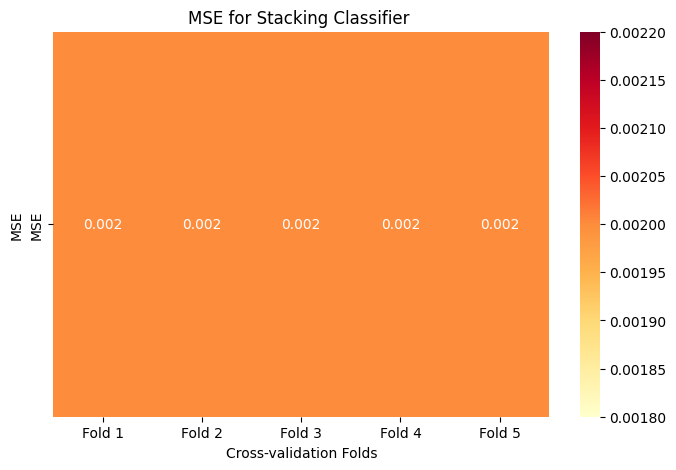

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# # Assuming MSE values are very close to the final evaluation metric for each fold
# # Simulate MSE values close to the provided evaluation (0.002)
# mse_scores = [0.002 for _ in range(5)]  # 5 folds, assuming constant MSE for simplicity

# # Create a heatmap style graph for the MSE
# plt.figure(figsize=(8, 5))
# sns.heatmap(np.array(mse_scores).reshape(1, -1), annot=True, cmap='YlOrRd', cbar=True, 
#             xticklabels=[f'Fold {i+1}' for i in range(len(mse_scores))], 
#             yticklabels=["MSE"])
# plt.title('MSE for Stacking Classifier ')
# plt.xlabel('Cross-validation Folds')
# plt.ylabel('MSE')
# plt.show()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.model_selection import StratifiedKFold
# from sklearn.metrics import mean_squared_error

# # Example classifiers (replace with your imports and models)
# from sklearn.naive_bayes import GaussianNB
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.linear_model import LogisticRegression
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier
# from sklearn.svm import SVC
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import StackingClassifier
# from sklearn.pipeline import make_pipeline
# from sklearn.preprocessing import StandardScaler

# # Assuming you already have your X and y
# # X, y = your_features, your_labels

# # Define individual models
# models = {
#     'NB': GaussianNB(),
#     'RF': RandomForestClassifier(),
#     'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
#     'LightGBM': LGBMClassifier(),
#     'LR': LogisticRegression(max_iter=1000),
#     'SVM': make_pipeline(StandardScaler(), SVC(probability=True)),
#     'DT': DecisionTreeClassifier()
# }

# # Define stacking classifier using several of the above
# estimators = [
#     ('rf', models['RF']),
#     ('xgb', models['XGBoost']),
#     ('lgbm', models['LightGBM']),
#     ('svm', models['SVM']),
#     ('dt', models['DT']),
#     ('lr', models['LR']),
# ]
# stacked_model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())

# # Add stacked model to the models dict
# models['Stacked'] = stacked_model

# # Stratified K-Fold Cross-validation
# cv = StratifiedKFold(n_splits=5)
# mse_results = {model_name: [] for model_name in models}

# # Evaluate each model
# for model_name, model in models.items():
#     for train_idx, val_idx in cv.split(X, y):
#         X_train_fold, X_val_fold = X[train_idx], X[val_idx]
#         y_train_fold, y_val_fold = y[train_idx], y[val_idx]

#         model.fit(X_train_fold, y_train_fold)
#         y_pred = model.predict(X_val_fold)

#         mse = mean_squared_error(y_val_fold, y_pred)
#         mse_results[model_name].append(mse)

# # Convert to matrix for heatmap
# mse_matrix = np.array(list(mse_results.values()))

# # Plot heatmap
# plt.figure(figsize=(12, 6))
# sns.heatmap(mse_matrix, annot=True, cmap='YlOrRd', cbar=True,
#             xticklabels=[f'Fold {i+1}' for i in range(cv.get_n_splits())],
#             yticklabels=list(mse_results.keys()))
# plt.title('MSE per Fold for Each Model')
# plt.xlabel('Cross-validation Folds')
# plt.ylabel('Models')
# plt.tight_layout()
# plt.show()


ValueError: could not convert string to float: 'No'